In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
MODEL_DIR = "../model"

os.makedirs(MODEL_DIR, exist_ok=True)

print("Model directory:", os.path.abspath(MODEL_DIR))

Model directory: h:\mlops\paper-assignment\model


In [3]:
df = pd.read_csv(
    "../dataset/processed/weather_normalized.csv"
)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (96453, 16)


,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Visibility (km),Pressure (millibars),Year,Month,Day,Hour,DayOfWeek,Wind Direction Sin,Wind Direction Cos,Precip Type_rain,Precip Type_snow,Summary
0,-0.257599,-0.324035,0.793470,0.478635,1.306976,0.101685,-1.581298,-1.021609,1.735129,1.516915,0.500259,-1.383077,-0.447730,1.0,0.0,Partly Cloudy
1,-0.269814,-0.339097,0.639996,0.499594,1.306976,0.105960,-1.581298,-1.021609,1.735129,1.661382,0.500259,-1.439500,-0.271765,1.0,0.0,Partly Cloudy
2,-0.267487,-0.138102,0.793470,-0.995473,1.099586,0.108610,-1.581298,-0.731626,-1.673122,-1.661351,1.000191,-0.541189,-1.215496,1.0,0.0,Mostly Cloudy
3,-0.381489,-0.459071,0.486521,0.476306,1.306976,0.112628,-1.581298,-0.731626,-1.673122,-1.516884,1.000191,-1.467971,-0.045400,1.0,0.0,Partly Cloudy
4,-0.332631,-0.362469,0.486521,0.033841,1.306976,0.113483,-1.581298,-0.731626,-1.673122,-1.372417,1.000191,-1.439500,-0.271765,1.0,0.0,Mostly Cloudy


In [4]:
print("Columns:")
for column in df.columns:
    print(column)

Columns:
Temperature (C)
Apparent Temperature (C)
Humidity
Wind Speed (km/h)
Visibility (km)
Pressure (millibars)
Year
Month
Day
Hour
DayOfWeek
Wind Direction Sin
Wind Direction Cos
Precip Type_rain
Precip Type_snow
Summary


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature (C)           96453 non-null  float64
 1   Apparent Temperature (C)  96453 non-null  float64
 2   Humidity                  96453 non-null  float64
 3   Wind Speed (km/h)         96453 non-null  float64
 4   Visibility (km)           96453 non-null  float64
 5   Pressure (millibars)      96453 non-null  float64
 6   Year                      96453 non-null  float64
 7   Month                     96453 non-null  float64
 8   Day                       96453 non-null  float64
 9   Hour                      96453 non-null  float64
 10  DayOfWeek                 96453 non-null  float64
 11  Wind Direction Sin        96453 non-null  float64
 12  Wind Direction Cos        96453 non-null  float64
 13  Precip Type_rain          96453 non-null  float64
 14  Precip Type_snow 

In [6]:
print("Total missing values:")
print(df.isnull().sum().sum())

print("\nMissing values by column:")
print(df.isnull().sum())

Total missing values:
0

Missing values by column:
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Visibility (km)             0
Pressure (millibars)        0
Year                        0
Month                       0
Day                         0
Hour                        0
DayOfWeek                   0
Wind Direction Sin          0
Wind Direction Cos          0
Precip Type_rain            0
Precip Type_snow            0
Summary                     0
dtype: int64


In [7]:
y = df["Summary"]

X = df.drop(columns=["Summary"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (96453, 15)
y shape: (96453,)


In [8]:
print("Number of classes:", y.nunique())

print("\nWeather classes:")
print(y.unique())

print("\nClass distribution:")
print(y.value_counts())

Number of classes: 27

Weather classes:
<StringArray>
[                      'Partly Cloudy',                       'Mostly Cloudy',
                            'Overcast',                               'Foggy',
            'Breezy and Mostly Cloudy',                               'Clear',
            'Breezy and Partly Cloudy',                 'Breezy and Overcast',
             'Humid and Mostly Cloudy',             'Humid and Partly Cloudy',
                     'Windy and Foggy',                  'Windy and Overcast',
                    'Breezy and Foggy',             'Windy and Partly Cloudy',
                              'Breezy',               'Dry and Partly Cloudy',
             'Windy and Mostly Cloudy', 'Dangerously Windy and Partly Cloudy',
                                 'Dry',                               'Windy',
                  'Humid and Overcast',                          'Light Rain',
                             'Drizzle',                       'Windy and Dry'

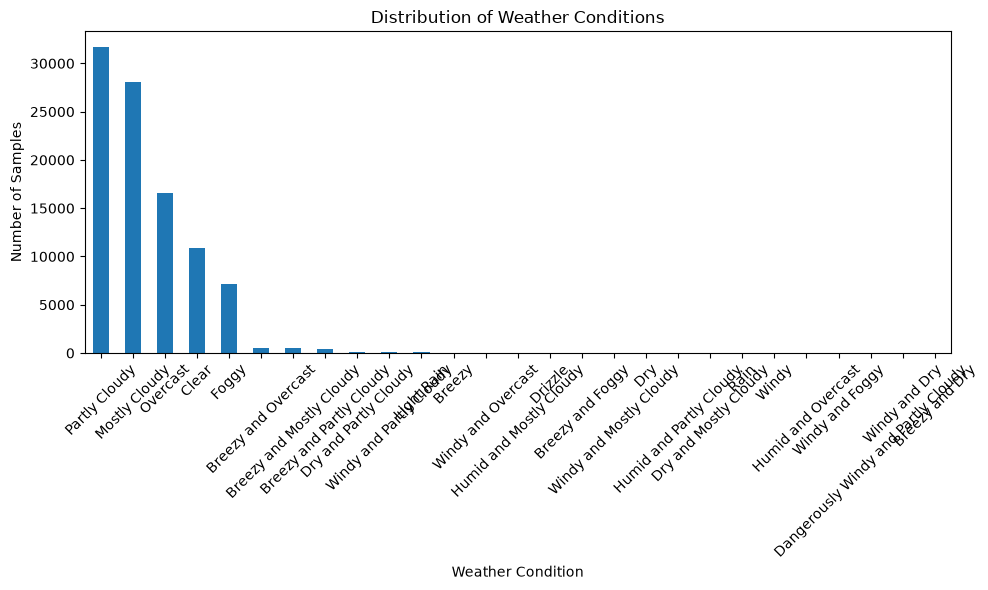

In [9]:
plt.figure(figsize=(10, 6))

y.value_counts().plot(kind="bar")

plt.title("Distribution of Weather Conditions")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(MODEL_DIR, "weather_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
class_counts = y.value_counts()

print("Original number of classes:", len(class_counts))

print("\nClasses with fewer than 2 samples:")
print(class_counts[class_counts < 2])


# Keep only classes with at least 2 samples
valid_classes = class_counts[class_counts >= 2].index

mask = y.isin(valid_classes)

X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)


print("\nAfter removing extremely rare classes:")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNumber of classes:", y.nunique())

Original number of classes: 27

Classes with fewer than 2 samples:
Summary
Dangerously Windy and Partly Cloudy    1
Windy and Dry                          1
Breezy and Dry                         1
Name: count, dtype: int64

After removing extremely rare classes:
X shape: (96450, 15)
y shape: (96450,)

Number of classes: 24


In [11]:
print(y.value_counts())

Summary
Partly Cloudy               31733
Mostly Cloudy               28094
Overcast                    16597
Clear                       10890
Foggy                        7148
Breezy and Overcast           528
Breezy and Mostly Cloudy      516
Breezy and Partly Cloudy      386
Dry and Partly Cloudy          86
Windy and Partly Cloudy        67
Light Rain                     63
Breezy                         54
Windy and Overcast             45
Humid and Mostly Cloudy        40
Drizzle                        39
Breezy and Foggy               35
Windy and Mostly Cloudy        35
Dry                            34
Humid and Partly Cloudy        17
Dry and Mostly Cloudy          14
Rain                           10
Windy                           8
Humid and Overcast              7
Windy and Foggy                 4
Name: count, dtype: int64


Splitting the Dataset to test train

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 77160
Testing samples: 19290


Logistic Regression model training

In [13]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [14]:
y_pred_lr = lr_model.predict(X_test)

print("Predictions generated.")

print("\nFirst 20 predictions:")
print(y_pred_lr[:20])

Predictions generated.

First 20 predictions:
['Partly Cloudy' 'Partly Cloudy' 'Clear' 'Mostly Cloudy' 'Mostly Cloudy'
 'Overcast' 'Overcast' 'Mostly Cloudy' 'Clear' 'Partly Cloudy' 'Overcast'
 'Mostly Cloudy' 'Partly Cloudy' 'Overcast' 'Partly Cloudy' 'Overcast'
 'Mostly Cloudy' 'Mostly Cloudy' 'Partly Cloudy' 'Breezy and Overcast']


In [15]:
lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

lr_precision = precision_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

print("Logistic Regression")
print("=" * 40)

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")

Logistic Regression
Accuracy : 0.5068
Precision: 0.5000
Recall   : 0.5068
F1 Score : 0.4828


In [16]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        zero_division=0
    )
)

                          precision    recall  f1-score   support

                  Breezy       0.40      0.18      0.25        11
        Breezy and Foggy       1.00      0.71      0.83         7
Breezy and Mostly Cloudy       0.40      0.29      0.34       103
     Breezy and Overcast       0.56      0.71      0.62       106
Breezy and Partly Cloudy       0.51      0.47      0.49        77
                   Clear       0.49      0.09      0.15      2178
                 Drizzle       0.00      0.00      0.00         8
                     Dry       0.50      0.14      0.22         7
   Dry and Mostly Cloudy       0.00      0.00      0.00         3
   Dry and Partly Cloudy       0.00      0.00      0.00        17
                   Foggy       0.88      0.97      0.92      1430
 Humid and Mostly Cloudy       0.00      0.00      0.00         8
      Humid and Overcast       0.00      0.00      0.00         1
 Humid and Partly Cloudy       0.00      0.00      0.00         3
         

Decision Tree Classifier training

In [17]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model.fit(
    X_train,
    y_train
)

print("Decision Tree training completed.")

Decision Tree training completed.


In [18]:
y_pred_dt = dt_model.predict(X_test)

print("Predictions generated.")

print("\nFirst 20 predictions:")
print(y_pred_dt[:20])

Predictions generated.

First 20 predictions:
['Overcast' 'Overcast' 'Clear' 'Mostly Cloudy' 'Partly Cloudy' 'Overcast'
 'Overcast' 'Overcast' 'Partly Cloudy' 'Mostly Cloudy' 'Clear'
 'Partly Cloudy' 'Partly Cloudy' 'Clear' 'Partly Cloudy' 'Partly Cloudy'
 'Overcast' 'Mostly Cloudy' 'Mostly Cloudy' 'Breezy and Mostly Cloudy']


In [19]:
dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

dt_precision = precision_score(
    y_test,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

dt_recall = recall_score(
    y_test,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

print("Decision Tree")
print("=" * 40)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")

Decision Tree
Accuracy : 0.5799
Precision: 0.5799
Recall   : 0.5799
F1 Score : 0.5798


In [20]:
print(
    classification_report(
        y_test,
        y_pred_dt,
        zero_division=0
    )
)

                          precision    recall  f1-score   support

                  Breezy       0.73      0.73      0.73        11
        Breezy and Foggy       1.00      0.86      0.92         7
Breezy and Mostly Cloudy       0.44      0.47      0.45       103
     Breezy and Overcast       0.57      0.59      0.58       106
Breezy and Partly Cloudy       0.58      0.49      0.53        77
                   Clear       0.51      0.50      0.50      2178
                 Drizzle       0.25      0.12      0.17         8
                     Dry       0.12      0.14      0.13         7
   Dry and Mostly Cloudy       0.33      0.67      0.44         3
   Dry and Partly Cloudy       0.17      0.06      0.09        17
                   Foggy       1.00      1.00      1.00      1430
 Humid and Mostly Cloudy       0.40      0.25      0.31         8
      Humid and Overcast       0.00      0.00      0.00         1
 Humid and Partly Cloudy       0.00      0.00      0.00         3
         

Random Forest model

In [21]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [22]:
y_pred_rf = rf_model.predict(X_test)

print("Predictions generated.")

print("\nFirst 20 predictions:")
print(y_pred_rf[:20])

Predictions generated.

First 20 predictions:
['Mostly Cloudy' 'Clear' 'Clear' 'Mostly Cloudy' 'Overcast' 'Overcast'
 'Overcast' 'Mostly Cloudy' 'Clear' 'Mostly Cloudy' 'Overcast'
 'Mostly Cloudy' 'Clear' 'Clear' 'Overcast' 'Overcast' 'Overcast'
 'Mostly Cloudy' 'Mostly Cloudy' 'Breezy and Mostly Cloudy']


In [23]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

print("Random Forest")
print("=" * 40)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

Random Forest
Accuracy : 0.6215
Precision: 0.6374
Recall   : 0.6215
F1 Score : 0.6175


In [24]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

                          precision    recall  f1-score   support

                  Breezy       0.90      0.82      0.86        11
        Breezy and Foggy       1.00      0.57      0.73         7
Breezy and Mostly Cloudy       0.56      0.58      0.57       103
     Breezy and Overcast       0.64      0.79      0.71       106
Breezy and Partly Cloudy       0.62      0.78      0.69        77
                   Clear       0.47      0.75      0.58      2178
                 Drizzle       0.50      0.38      0.43         8
                     Dry       0.50      0.29      0.36         7
   Dry and Mostly Cloudy       0.50      0.67      0.57         3
   Dry and Partly Cloudy       0.44      0.65      0.52        17
                   Foggy       0.99      1.00      1.00      1430
 Humid and Mostly Cloudy       0.38      0.38      0.38         8
      Humid and Overcast       0.00      0.00      0.00         1
 Humid and Partly Cloudy       0.50      0.33      0.40         3
         

Saving the results

In [25]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.506791,0.500050,0.506791,0.482804
1,Decision Tree,0.579886,0.579861,0.579886,0.579774
2,Random Forest,0.621462,0.637407,0.621462,0.617493


In [26]:
results_rounded = results.copy()

results_rounded[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
] = results_rounded[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].round(4)

results_rounded

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.5068,0.5000,0.5068,0.4828
1,Decision Tree,0.5799,0.5799,0.5799,0.5798
2,Random Forest,0.6215,0.6374,0.6215,0.6175


In [27]:
results_rounded.to_csv(
    os.path.join(
        MODEL_DIR,
        "model_results.csv"
    ),
    index=False
)

print("Model results saved.")

Model results saved.


In [28]:
results_rounded.to_csv(
    os.path.join(
        MODEL_DIR,
        "model_results.csv"
    ),
    index=False
)

print("Model results saved.")

Model results saved.


Comparing all the results

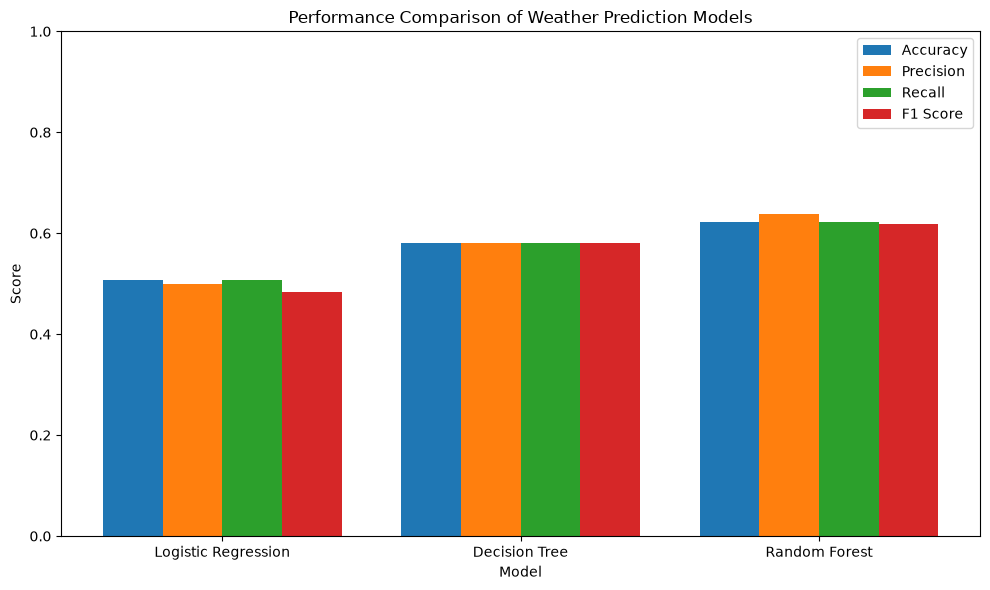

In [29]:
plt.figure(figsize=(10, 6))

x = np.arange(len(results["Model"]))
width = 0.2

plt.bar(
    x - 1.5 * width,
    results["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x - 0.5 * width,
    results["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x + 0.5 * width,
    results["Recall"],
    width,
    label="Recall"
)

plt.bar(
    x + 1.5 * width,
    results["F1 Score"],
    width,
    label="F1 Score"
)

plt.xticks(
    x,
    results["Model"]
)

plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Performance Comparison of Weather Prediction Models")

plt.ylim(0, 1)
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        MODEL_DIR,
        "model_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
cm = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=rf_model.classes_
)

print(cm)

[[   9    0    0    1    1    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0]
 [   0    4    0    0    0    0    0    0    0    0    3    0    0    0
     0    0    0    0    0    0    0    0    0    0]
 [   0    0   60   26   16    0    0    0    0    1    0    0    0    0
     0    0    0    0    0    0    0    0    0    0]
 [   0    0   19   84    3    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0]
 [   0    0   14    3   60    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0]
 [   1    0    0    0    0 1637    0    2    0    2    4    0    0    0
     0   91  136  305    0    0    0    0    0    0]
 [   0    0    0    0    0    0    3    0    0    0    0    0    0    0
     3    1    0    1    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    2    0    3    0    0    0    0
     0    0    0    2    0    0    0    0    0    0]


Confusion Matrix

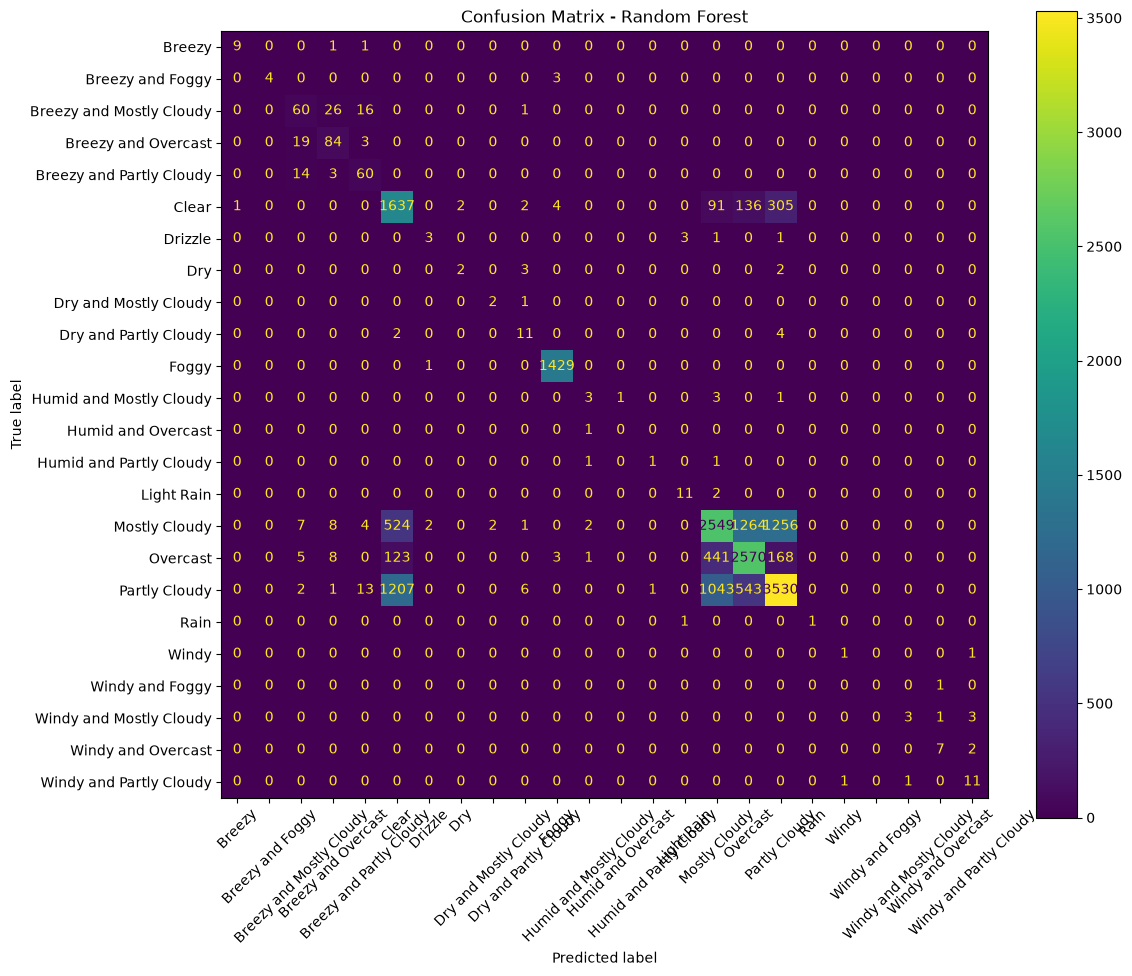

In [31]:
fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix - Random Forest")

plt.tight_layout()

plt.savefig(
    os.path.join(
        MODEL_DIR,
        "random_forest_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
3,Wind Speed (km/h),0.154624
2,Humidity,0.117022
5,Pressure (millibars),0.105783
4,Visibility (km),0.098640
1,Apparent Temperature (C),0.090963
0,Temperature (C),0.085363
6,Year,0.064563
9,Hour,0.055445
12,Wind Direction Cos,0.051488
11,Wind Direction Sin,0.050415


In [33]:
feature_importance.to_csv(
    os.path.join(
        MODEL_DIR,
        "feature_importance.csv"
    ),
    index=False
)

print("Feature importance saved.")

Feature importance saved.


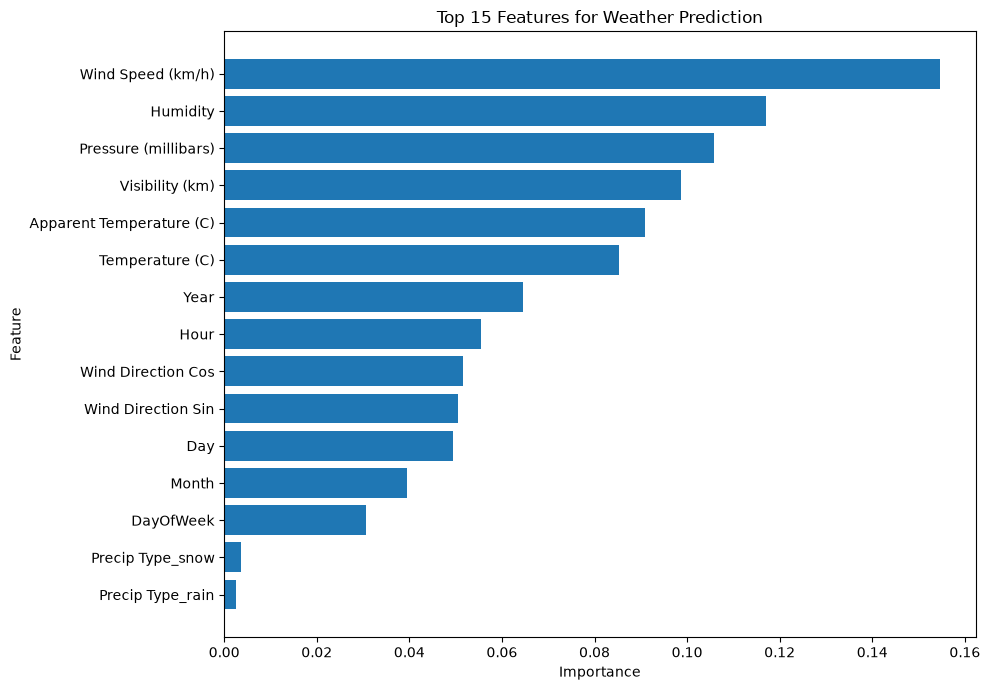

In [34]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features for Weather Prediction")

plt.tight_layout()

plt.savefig(
    os.path.join(
        MODEL_DIR,
        "feature_importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Saving the Best model

In [35]:
best_model_name = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]

print("Best model:", best_model_name)

Best model: Random Forest


Validating the Best model

In [36]:
if best_model_name == "Logistic Regression":
    best_model = lr_model
    best_predictions = y_pred_lr

elif best_model_name == "Decision Tree":
    best_model = dt_model
    best_predictions = y_pred_dt

else:
    best_model = rf_model
    best_predictions = y_pred_rf

print("Selected:", best_model_name)

Selected: Random Forest


In [37]:
model_path = os.path.join(
    MODEL_DIR,
    "weather_prediction_model.pkl"
)

joblib.dump(
    best_model,
    model_path
)

print("Best model saved to:")
print(model_path)

Best model saved to:
../model\weather_prediction_model.pkl


In [38]:
metadata = {
    "model": best_model_name,
    "random_state": 42,
    "test_size": 0.20,
    "number_of_features": X.shape[1],
    "number_of_classes": y.nunique(),
    "accuracy": float(
        accuracy_score(y_test, best_predictions)
    ),
    "precision": float(
        precision_score(
            y_test,
            best_predictions,
            average="weighted",
            zero_division=0
        )
    ),
    "recall": float(
        recall_score(
            y_test,
            best_predictions,
            average="weighted",
            zero_division=0
        )
    ),
    "f1_score": float(
        f1_score(
            y_test,
            best_predictions,
            average="weighted",
            zero_division=0
        )
    )
}

metadata

{'model': 'Random Forest',
 'random_state': 42,
 'test_size': 0.2,
 'number_of_features': 15,
 'number_of_classes': 24,
 'accuracy': 0.6214618973561431,
 'precision': 0.6374074372564861,
 'recall': 0.6214618973561431,
 'f1_score': 0.6174929164067197}

In [39]:
import json

with open(
    os.path.join(
        MODEL_DIR,
        "model_metadata.json"
    ),
    "w"
) as file:

    json.dump(
        metadata,
        file,
        indent=4
    )

print("Metadata saved.")

Metadata saved.


In [40]:
loaded_model = joblib.load(
    "../model/weather_prediction_model.pkl"
)

print("Model loaded successfully.")

Model loaded successfully.


In [41]:
sample = X_test.iloc[[0]]

actual = y_test.iloc[0]

prediction = loaded_model.predict(sample)[0]

print("Actual condition    :", actual)
print("Predicted condition :", prediction)

Actual condition    : Overcast
Predicted condition : Mostly Cloudy


In [42]:
sample_data = X_test.iloc[:10]

actual_values = y_test.iloc[:10]

predicted_values = loaded_model.predict(
    sample_data
)

prediction_results = pd.DataFrame({
    "Actual": actual_values.values,
    "Predicted": predicted_values
})

prediction_results

,Actual,Predicted
0,Overcast,Mostly Cloudy
1,Clear,Clear
2,Clear,Clear
3,Overcast,Mostly Cloudy
4,Mostly Cloudy,Overcast
5,Overcast,Overcast
6,Overcast,Overcast
7,Mostly Cloudy,Mostly Cloudy
8,Partly Cloudy,Clear
9,Overcast,Mostly Cloudy


In [43]:
sample = X_test.iloc[[0]]

probabilities = loaded_model.predict_proba(sample)[0]

probability_df = pd.DataFrame({
    "Weather Condition": loaded_model.classes_,
    "Probability": probabilities
})

probability_df = probability_df.sort_values(
    by="Probability",
    ascending=False
)

probability_df

,Weather Condition,Probability
15,Mostly Cloudy,0.360
17,Partly Cloudy,0.315
16,Overcast,0.270
5,Clear,0.050
2,Breezy and Mostly Cloudy,0.005
3,Breezy and Overcast,0.000
1,Breezy and Foggy,0.000
0,Breezy,0.000
7,Dry,0.000
6,Drizzle,0.000
